# 🏭 Projet — Maintenance Prédictive Industrielle
## Prédiction de la Durée de Vie Restante (RUL — Remaining Useful Life)

**Tâche choisie :** Régression — estimation du nombre d'heures restantes avant défaillance (`rul_hours`)  
**Dataset :** `predictive_maintenance_v3.csv` — 24 042 enregistrements, 15 variables  
**Modèles comparés :** Régression Linéaire · Random Forest · XGBoost · MLP (Deep Learning)  

---

## 1. Imports & Configuration

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import shap
import joblib
import os

# Reproductibilité
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Style graphique
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')

print('✅ Imports OK')

✅ Imports OK


## 2. Chargement & Premier Aperçu

In [75]:
df = pd.read_csv('predictive_maintenance_v3.csv', parse_dates=['timestamp'])
print(f'Shape : {df.shape}')
df.head()

Shape : (24042, 15)


,timestamp,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,failure_type,estimated_repair_cost
0,2024-01-01 00:00:00,1,CNC,0.81,49.51,5.10,23.6,860.9,idle,273.80,13.9,61.00,0,none,0
1,2024-01-01 00:03:00,1,CNC,0.75,40.58,5.30,23.6,899.6,idle,273.85,10.2,60.95,0,none,0
2,2024-01-01 00:21:00,1,CNC,0.71,49.70,NaN,21.3,862.7,idle,274.15,13.6,60.65,0,none,0
3,2024-01-01 00:45:00,1,CNC,0.76,43.04,4.79,22.6,870.4,idle,274.55,13.4,60.25,0,none,0
4,2024-01-01 00:54:00,1,CNC,0.88,41.39,4.44,22.2,881.9,idle,274.70,10.8,60.10,0,none,0


In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24042 entries, 0 to 24041
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   timestamp                24042 non-null  datetime64[ns]
 1   machine_id               24042 non-null  int64         
 2   machine_type             24042 non-null  object        
 3   vibration_rms            23042 non-null  float64       
 4   temperature_motor        23208 non-null  float64       
 5   current_phase_avg        23311 non-null  float64       
 6   pressure_level           23118 non-null  float64       
 7   rpm                      23509 non-null  float64       
 8   operating_mode           24042 non-null  object        
 9   hours_since_maintenance  24042 non-null  float64       
 10  ambient_temp             24042 non-null  float64       
 11  rul_hours                24042 non-null  float64       
 12  failure_within_24h       24042 n

In [77]:
df.describe().round(2)

,timestamp,machine_id,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,estimated_repair_cost
count,24042,24042.00,23042.00,23208.00,23311.00,23118.00,23509.00,24042.00,24042.00,24042.00,24042.00,24042.00
mean,2024-01-08 00:06:30.111721216,10.51,1.62,51.40,8.82,59.01,1144.85,172.63,13.00,27.81,0.15,608.87
min,2024-01-01 00:00:00,1.00,0.35,28.00,2.20,10.10,124.10,0.00,8.00,0.50,0.00,0.00
25%,2024-01-04 12:24:13.750000128,6.00,0.82,42.61,4.63,22.70,489.40,42.87,10.50,0.50,0.00,0.00
50%,2024-01-08 00:11:30,10.00,1.27,50.06,6.43,46.30,856.00,121.61,13.00,22.57,0.00,0.00
75%,2024-01-11 13:24:32.500000,15.00,2.27,59.96,13.12,94.70,1676.00,295.58,15.50,46.41,0.00,0.00
max,2024-01-14 23:59:38,20.00,10.00,95.00,35.00,206.50,4098.80,575.63,18.00,98.34,1.00,7995.00
std,NaN,5.75,1.08,12.52,5.37,38.72,912.67,150.72,2.88,26.39,0.36,1566.79


## 3. Analyse Exploratoire des Données (EDA)

### 3.1 Valeurs Manquantes

Variables avec valeurs manquantes :
                   Count  Pct (%)
vibration_rms       1000     4.16
pressure_level       924     3.84
temperature_motor    834     3.47
current_phase_avg    731     3.04
rpm                  533     2.22


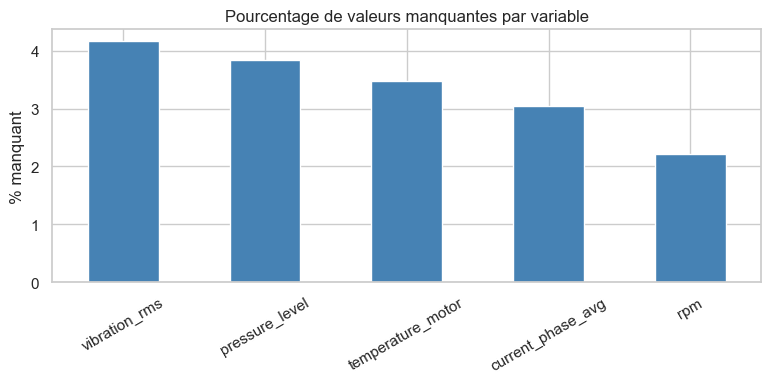

In [78]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Pct (%)': missing_pct})
missing_df = missing_df[missing_df['Count'] > 0].sort_values('Pct (%)', ascending=False)

print('Variables avec valeurs manquantes :')
print(missing_df)

plt.figure(figsize=(8, 4))
missing_df['Pct (%)'].plot(kind='bar', color='steelblue')
plt.title('Pourcentage de valeurs manquantes par variable')
plt.ylabel('% manquant')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Commentaire : toutes les valeurs manquantes sont < 5% → imputation par médiane acceptable

### 3.2 Distribution de la Variable Cible (rul_hours)

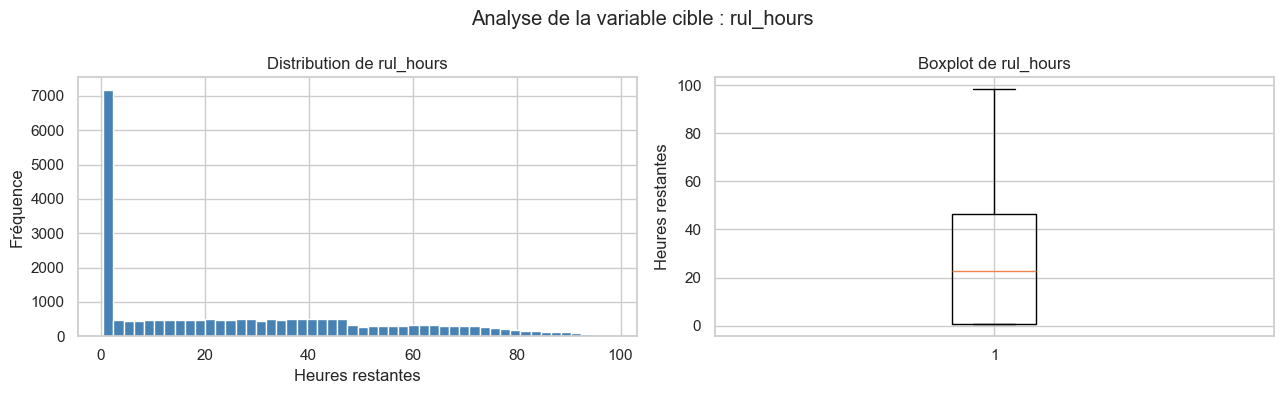

Min : 0.50 h
Max : 98.34 h
Médiane : 22.57 h
Moyenne : 27.81 h
Std : 26.39 h


In [79]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['rul_hours'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution de rul_hours')
axes[0].set_xlabel('Heures restantes')
axes[0].set_ylabel('Fréquence')

axes[1].boxplot(df['rul_hours'], vert=True)
axes[1].set_title('Boxplot de rul_hours')
axes[1].set_ylabel('Heures restantes')

plt.suptitle('Analyse de la variable cible : rul_hours')
plt.tight_layout()
plt.show()

print(f"Min : {df['rul_hours'].min():.2f} h")
print(f"Max : {df['rul_hours'].max():.2f} h")
print(f"Médiane : {df['rul_hours'].median():.2f} h")
print(f"Moyenne : {df['rul_hours'].mean():.2f} h")
print(f"Std : {df['rul_hours'].std():.2f} h")

# Commentaire : distribution bimodale avec pic à 0.5h (machines proches de la panne)
# et une queue vers 98h. Pas de transformation log nécessaire mais à tester.

### 3.3 Variables Catégorielles

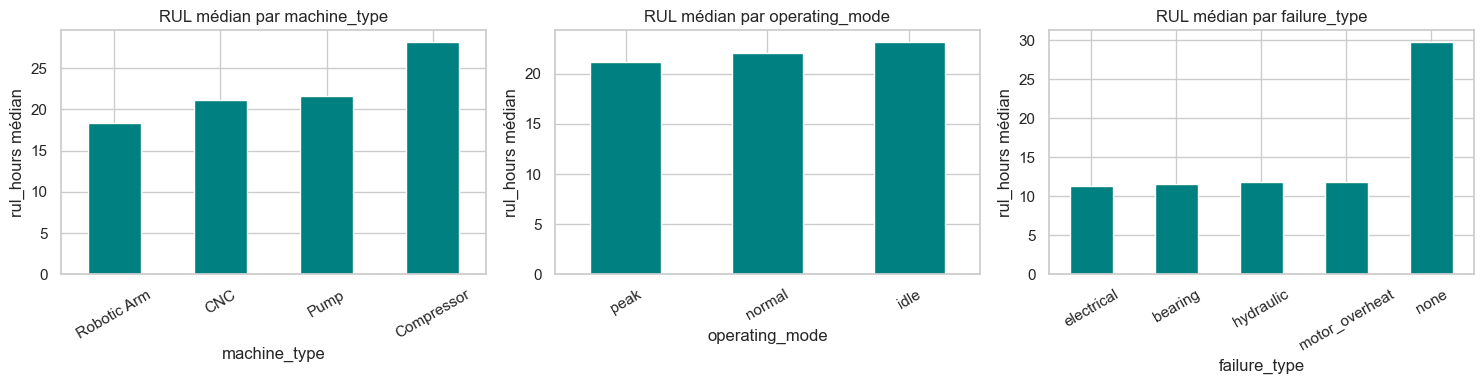

In [80]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['machine_type', 'operating_mode', 'failure_type']):
    df.groupby(col)['rul_hours'].median().sort_values().plot(kind='bar', ax=ax, color='teal')
    ax.set_title(f'RUL médian par {col}')
    ax.set_ylabel('rul_hours médian')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 3.4 Corrélations entre Variables Numériques

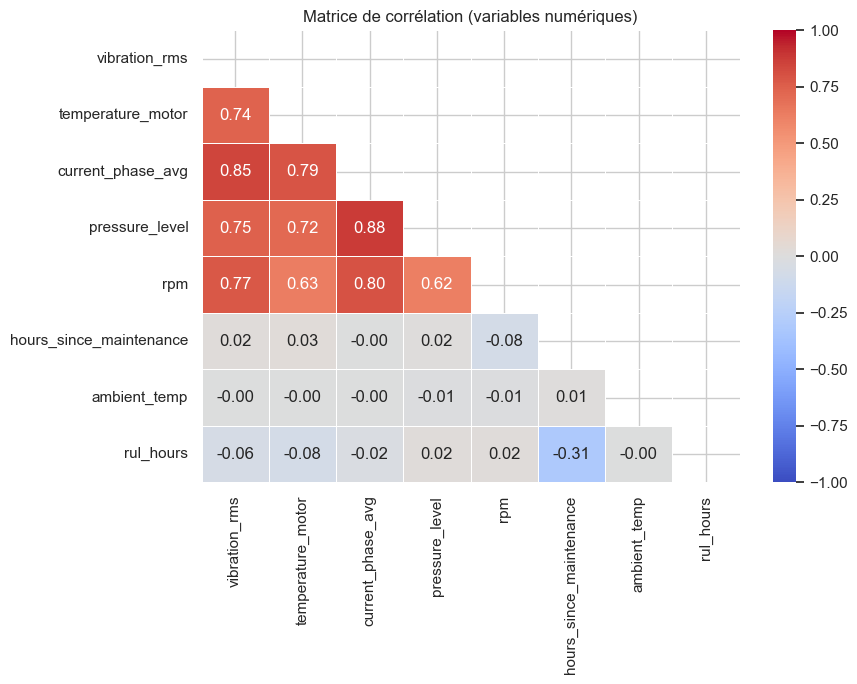

Corrélation avec rul_hours :
hours_since_maintenance   -0.307
temperature_motor         -0.078
vibration_rms             -0.057
current_phase_avg         -0.025
pressure_level             0.022
rpm                        0.017
ambient_temp              -0.004
Name: rul_hours, dtype: float64


In [81]:
num_cols = ['vibration_rms', 'temperature_motor', 'current_phase_avg',
            'pressure_level', 'rpm', 'hours_since_maintenance', 'ambient_temp', 'rul_hours']

corr = df[num_cols].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matrice de corrélation (variables numériques)')
plt.tight_layout()
plt.show()

print('Corrélation avec rul_hours :')
print(corr['rul_hours'].drop('rul_hours').sort_values(key=abs, ascending=False).round(3))

Conclusion : Quand la vibration monte, le courant, la pression et le RPM montent aussi — ce sont des signaux physiquement liés, une machine qui s'emballe sur un capteur s'emballe sur tous. Cela crée de la multicolinéarité, ce qui peut poser problème pour la Ridge Regression mais pas pour Random Forest ou XGBoost.

### 3.5 Distribution des Capteurs par Type de Machine

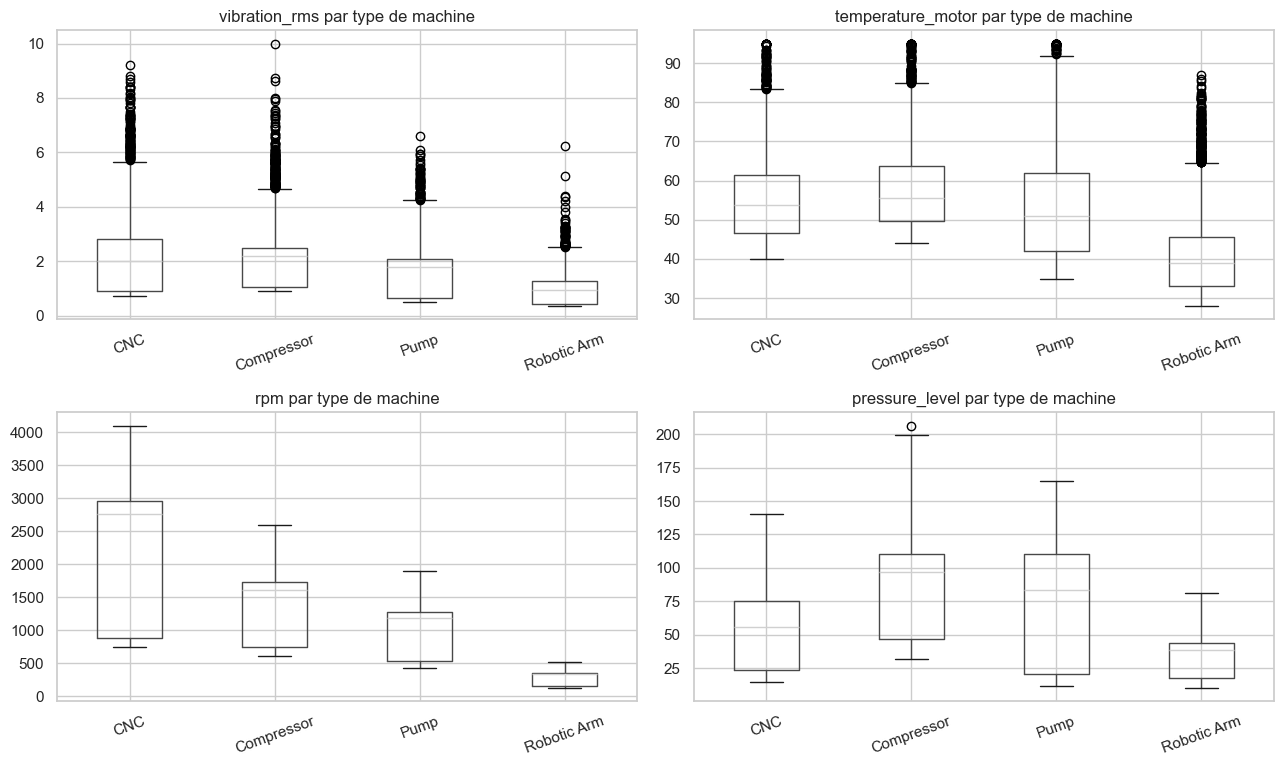

In [82]:
sensors = ['vibration_rms', 'temperature_motor', 'rpm', 'pressure_level']
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for ax, col in zip(axes.flatten(), sensors):
    df.boxplot(column=col, by='machine_type', ax=ax)
    ax.set_title(f'{col} par type de machine')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('')
plt.tight_layout()
plt.show()

### 3.6 Évolution du RUL dans le temps (pour 1 machine)

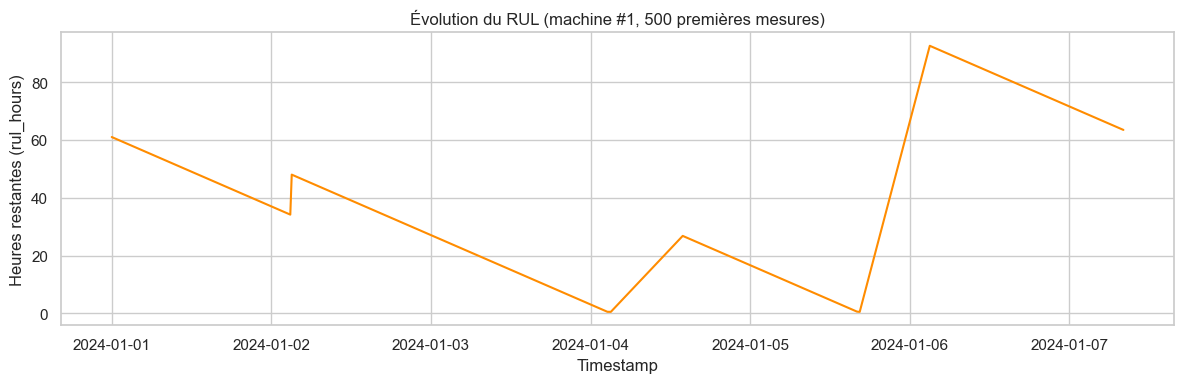

In [83]:
machine_sample = df[df['machine_id'] == 1].sort_values('timestamp').head(500)

plt.figure(figsize=(12, 4))
plt.plot(machine_sample['timestamp'], machine_sample['rul_hours'], color='darkorange', lw=1.5)
plt.title('Évolution du RUL (machine #1, 500 premières mesures)')
plt.xlabel('Timestamp')
plt.ylabel('Heures restantes (rul_hours)')
plt.tight_layout()
plt.show()

## 4. Préparation des Données

In [84]:
# ── 1. cumcount : nb mesures écoulées depuis le début du cycle ───────────
#    Disponible en temps réel → pas de data leakage
df['cumcount'] = df.groupby('machine_id').cumcount()

# ── 2. Relation non-linéaire avec le temps ───────────────────────────────
df['hours_sq'] = df['hours_since_maintenance'] ** 2

# ── 3. Interactions physiques entre capteurs ─────────────────────────────
df['vib_x_temp']   = df['vibration_rms'] * df['temperature_motor']
df['vib_x_hours']  = df['vibration_rms'] * df['hours_since_maintenance']
df['temp_x_hours'] = df['temperature_motor'] * df['hours_since_maintenance']

print('Nouvelles features créées :')
print('  cumcount : nb mesures depuis début du cycle (proxy du vieillissement)')
print('  hours_sq : relation non-linéaire avec le temps')
print('  vib_x_temp : stress thermomécanique combiné')
print('  vib_x_hours : vibration cumulée dans le temps')
print('  temp_x_hours : chaleur cumulée dans le temps')

# ── Préparation du dataset ───────────────────────────────────────────────
DROP = ['timestamp', 'machine_id', 'failure_within_24h',
        'failure_type', 'estimated_repair_cost']
TARGET = 'rul_hours'

df_model = df.drop(columns=DROP)
df_model['machine_type_enc']   = pd.Categorical(df_model['machine_type']).codes
df_model['operating_mode_enc'] = pd.Categorical(df_model['operating_mode']).codes
df_model = df_model.drop(columns=['machine_type', 'operating_mode'])
df_model = df_model.fillna(df_model.median(numeric_only=True))

X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

print(f'\nDataset final : {X.shape[0]} lignes × {X.shape[1]} features')
print('Features :', list(X.columns))

Nouvelles features créées :
  cumcount : nb mesures depuis début du cycle (proxy du vieillissement)
  hours_sq : relation non-linéaire avec le temps
  vib_x_temp : stress thermomécanique combiné
  vib_x_hours : vibration cumulée dans le temps
  temp_x_hours : chaleur cumulée dans le temps

Dataset final : 24042 lignes × 14 features
Features : ['vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'hours_since_maintenance', 'ambient_temp', 'cumcount', 'hours_sq', 'vib_x_temp', 'vib_x_hours', 'temp_x_hours', 'machine_type_enc', 'operating_mode_enc']


In [85]:
# ─── 4.2 Séparation Train / Test ────────────────────────────────────────
# Stratification non applicable en régression → split simple avec shuffle
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Train : {X_train.shape[0]} samples')
print(f'Test  : {X_test.shape[0]} samples')

Train : 19233 samples
Test  : 4809 samples


In [86]:
# ─── 4.3 Pipeline de Préprocessing ──────────────────────────────────────
# Séparation colonnes numériques / catégorielles
num_features = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_features = X.select_dtypes(include=['object', 'string']).columns.tolist()

print('Numériques :', num_features)
print('Catégorielles :', cat_features)

# Imputation médiane + standardisation pour variables numériques
# Imputation mode + OneHotEncoding pour variables catégorielles
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

print('\n✅ Preprocessor défini (ajusté uniquement sur X_train → pas de data leakage)')

Numériques : ['vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'hours_since_maintenance', 'ambient_temp', 'cumcount', 'hours_sq', 'vib_x_temp', 'vib_x_hours', 'temp_x_hours']
Catégorielles : []

✅ Preprocessor défini (ajusté uniquement sur X_train → pas de data leakage)


## 5. Modélisation Multi-Algorithmes

| Modèle | Type | Justification |
|--------|------|---------------|
| Ridge Regression | Baseline linéaire | Interprétable, robuste à la multicolinéarité |
| Random Forest | Ensemble bagging | Capture les non-linéarités, peu sensible aux outliers |
| XGBoost | Ensemble boosting | Performances état de l'art sur données tabulaires |
| MLP (sklearn) | Deep Learning | Modélise des interactions complexes entre capteurs |

In [87]:
# Définition des modèles dans des pipelines complets
models = {
    'Ridge Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('model', Ridge(alpha=1.0))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=200, max_depth=15,
            min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=-1
        ))
    ]),
    'XGBoost': Pipeline([
        ('preprocessor', preprocessor),
        ('model', xgb.XGBRegressor(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
        ))
    ]),
    'MLP (Deep Learning)': Pipeline([
        ('preprocessor', preprocessor),
        ('model', MLPRegressor(
            hidden_layer_sizes=(256, 128, 64),
            activation='relu', solver='adam',
            max_iter=300, learning_rate_init=0.001,
            early_stopping=True, validation_fraction=0.1,
            random_state=RANDOM_STATE
        ))
    ]),
}

print('✅ 4 modèles définis (Ridge, RF, XGBoost, MLP)')

✅ 4 modèles définis (Ridge, RF, XGBoost, MLP)


## 6. Entraînement & Évaluation

In [88]:
def evaluate_model(name, pipeline, X_train, X_test, y_train, y_test):
    """Entraîne, prédit et retourne les métriques."""
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_pred = np.clip(y_pred, 0, None)  # RUL ne peut pas être négatif
    
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    
    return {'MAE': round(mae, 3), 'RMSE': round(rmse, 3), 'R²': round(r2, 4)}, y_pred


results = {}
predictions = {}

for name, pipeline in models.items():
    print(f'⏳ Entraînement : {name}...', end=' ')
    metrics, y_pred = evaluate_model(name, pipeline, X_train, X_test, y_train, y_test)
    results[name] = metrics
    predictions[name] = y_pred
    print(f"MAE={metrics['MAE']}  RMSE={metrics['RMSE']}  R²={metrics['R²']}")

print('\n✅ Entraînement terminé')

⏳ Entraînement : Ridge Regression... MAE=16.288  RMSE=20.468  R²=0.3941
⏳ Entraînement : Random Forest... MAE=3.077  RMSE=5.575  R²=0.955
⏳ Entraînement : XGBoost... MAE=4.402  RMSE=6.542  R²=0.9381
⏳ Entraînement : MLP (Deep Learning)... MAE=4.911  RMSE=7.604  R²=0.9164

✅ Entraînement terminé


### 6.1 Tableau Comparatif des Performances

=== TABLEAU COMPARATIF DES MODÈLES ===
                        MAE    RMSE      R²
Random Forest         3.077   5.575  0.9550
XGBoost               4.402   6.542  0.9381
MLP (Deep Learning)   4.911   7.604  0.9164
Ridge Regression     16.288  20.468  0.3941


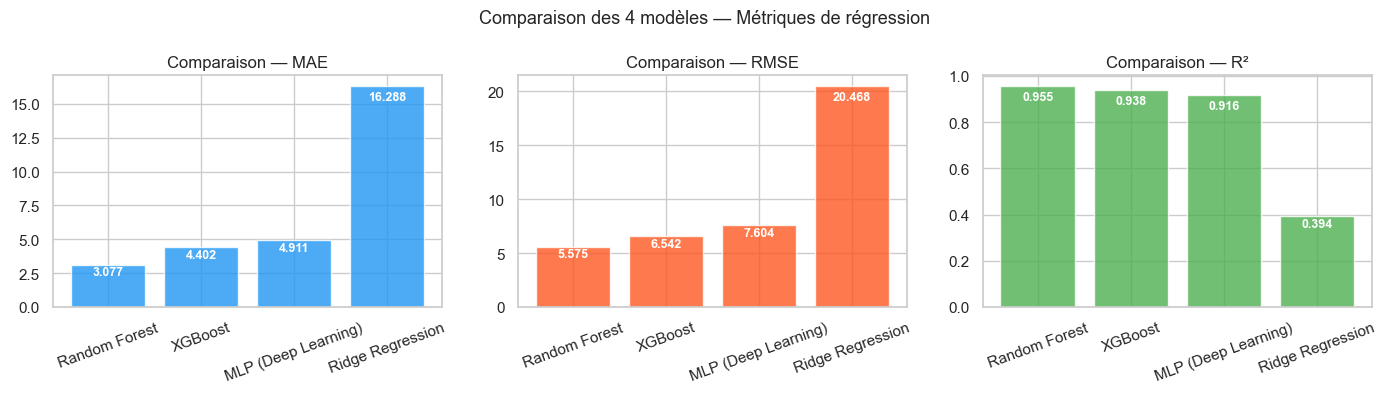

In [89]:
results_df = pd.DataFrame(results).T.sort_values('RMSE')
print('=== TABLEAU COMPARATIF DES MODÈLES ===')
print(results_df.to_string())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics_plot = ['MAE', 'RMSE', 'R²']
colors = ['#2196F3', '#FF5722', '#4CAF50']

for ax, metric, color in zip(axes, metrics_plot, colors):
    vals = results_df[metric]
    bars = ax.bar(vals.index, vals, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'Comparaison — {metric}')
    ax.tick_params(axis='x', rotation=20)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 0.98,
                f'{v:.3f}', ha='center', va='top', fontsize=9, color='white', fontweight='bold')

plt.suptitle('Comparaison des 4 modèles — Métriques de régression', fontsize=13)
plt.tight_layout()
plt.show()

### 6.2 Validation Croisée (Robustesse)

In [90]:
# Cross-validation 5-fold sur l'ensemble du dataset (train+test)
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}
for name, pipeline in models.items():
    scores = cross_val_score(
        pipeline, X, y, cv=kf,
        scoring='neg_mean_absolute_error', n_jobs=-1
    )
    mae_scores = -scores
    cv_results[name] = {
        'CV MAE Mean': round(mae_scores.mean(), 3),
        'CV MAE Std': round(mae_scores.std(), 3)
    }
    print(f'{name}: MAE = {mae_scores.mean():.3f} ± {mae_scores.std():.3f}')

cv_df = pd.DataFrame(cv_results).T
print()
print(cv_df)

/Users/coulibalycheickmohamedtidiane/Projet_data_science_maintenance_predictive/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/coulibalycheickmohamedtidiane/Projet_data_science_maintenance_predictive/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/coulibalycheickmohamedtidiane/Projet_data_science_maintenance_predictive/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/coulibalycheickmohamedtidiane/Projet_data_science_maintenance_predictive/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/coulibalycheickmohamedtidiane/Projet_data_science_maintenance_predictive/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow

Ridge Regression: MAE = 16.603 ± 0.114
Random Forest: MAE = 3.097 ± 0.073
XGBoost: MAE = 4.430 ± 0.114


/Users/coulibalycheickmohamedtidiane/Projet_data_science_maintenance_predictive/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/coulibalycheickmohamedtidiane/Projet_data_science_maintenance_predictive/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/coulibalycheickmohamedtidiane/Projet_data_science_maintenance_predictive/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/coulibalycheickmohamedtidiane/Projet_data_science_maintenance_predictive/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/coulibalycheickmohamedtidiane/Projet_data_science_maintenance_predictive/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow

MLP (Deep Learning): MAE = 4.943 ± 0.200

                     CV MAE Mean  CV MAE Std
Ridge Regression          16.603       0.114
Random Forest              3.097       0.073
XGBoost                    4.430       0.114
MLP (Deep Learning)        4.943       0.200


/Users/coulibalycheickmohamedtidiane/Projet_data_science_maintenance_predictive/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/coulibalycheickmohamedtidiane/Projet_data_science_maintenance_predictive/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/coulibalycheickmohamedtidiane/Projet_data_science_maintenance_predictive/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/coulibalycheickmohamedtidiane/Projet_data_science_maintenance_predictive/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/coulibalycheickmohamedtidiane/Projet_data_science_maintenance_predictive/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow

### 6.3 Analyse des Résidus — Meilleur Modèle

🏆 Meilleur modèle : Random Forest


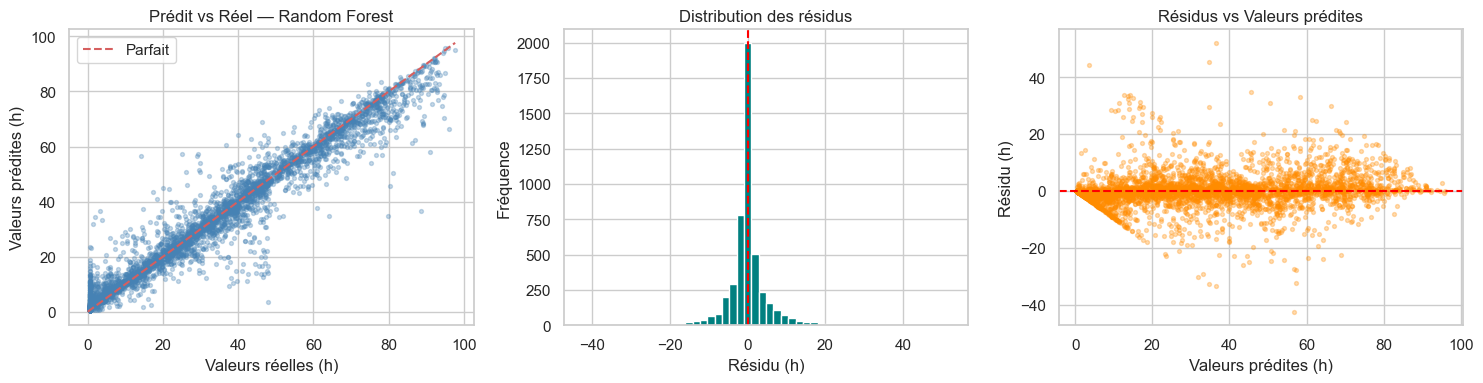

In [91]:
# Sélection automatique du meilleur modèle (RMSE)
best_model_name = results_df['RMSE'].idxmin()
print(f'🏆 Meilleur modèle : {best_model_name}')

best_pipeline = models[best_model_name]
y_pred_best = predictions[best_model_name]
residuals = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Prédit vs Réel
axes[0].scatter(y_test, y_pred_best, alpha=0.3, s=8, color='steelblue')
lim = [0, max(y_test.max(), y_pred_best.max())]
axes[0].plot(lim, lim, 'r--', lw=1.5, label='Parfait')
axes[0].set_xlabel('Valeurs réelles (h)')
axes[0].set_ylabel('Valeurs prédites (h)')
axes[0].set_title(f'Prédit vs Réel — {best_model_name}')
axes[0].legend()

# Distribution des résidus
axes[1].hist(residuals, bins=50, color='teal', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Distribution des résidus')
axes[1].set_xlabel('Résidu (h)')
axes[1].set_ylabel('Fréquence')

# Résidus vs valeurs prédites
axes[2].scatter(y_pred_best, residuals, alpha=0.3, s=8, color='darkorange')
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_title('Résidus vs Valeurs prédites')
axes[2].set_xlabel('Valeurs prédites (h)')
axes[2].set_ylabel('Résidu (h)')

plt.tight_layout()
plt.show()

## 7. Interprétabilité — Feature Importance

### 7.1 Importance Native (Random Forest)

Nb feature_names après preprocessor : 12
Nb importances dans le modèle       : 12
Features : ['vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'hours_since_maintenance', 'ambient_temp', 'cumcount', 'hours_sq', 'vib_x_temp', 'vib_x_hours', 'temp_x_hours']


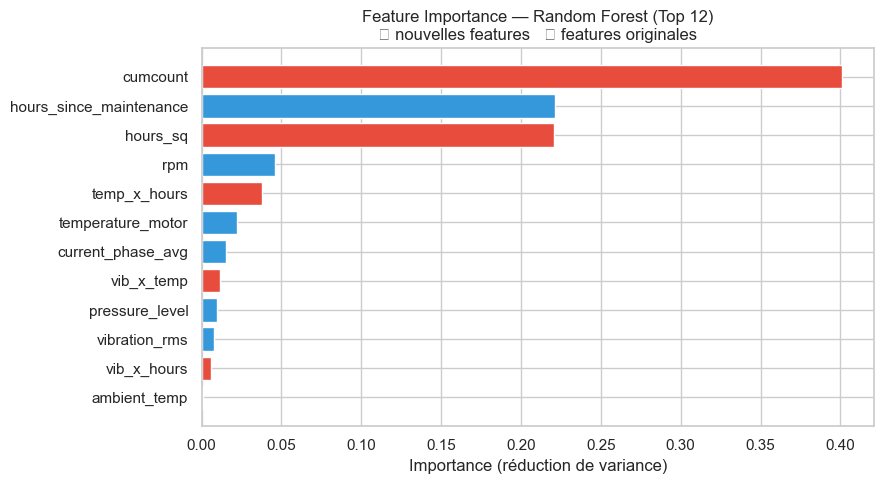


Contribution nouvelles features  : 67.7%
Contribution features originales : 32.3%


In [92]:
# ── 7.1 Feature Importance Native (Random Forest) ──────────────────────

rf_pipeline = models['Random Forest']
rf_model    = rf_pipeline.named_steps['model']
preprocessor_fitted = rf_pipeline.named_steps['preprocessor']

# Récupérer les vrais noms de features après transformation du preprocessor
# C'est le seul moyen fiable quand cat_features = []
feature_names = preprocessor_fitted.get_feature_names_out()

# Nettoyer les noms (sklearn ajoute un préfixe "num__")
feature_names = [name.replace('num__', '').replace('cat__', '') 
                 for name in feature_names]

importances = rf_model.feature_importances_

print(f"Nb feature_names après preprocessor : {len(feature_names)}")
print(f"Nb importances dans le modèle       : {len(importances)}")
print(f"Features : {feature_names}")

fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=True).tail(12)

plt.figure(figsize=(9, 5))
colors = ['#e74c3c' if any(k in f for k in ['cumcount', 'hours_sq', '_x_'])
          else '#3498db' for f in fi_df['Feature']]
plt.barh(fi_df['Feature'], fi_df['Importance'], color=colors)
plt.title('Feature Importance — Random Forest (Top 12)\n🔴 nouvelles features   🔵 features originales')
plt.xlabel('Importance (réduction de variance)')
plt.tight_layout()
plt.show()

new_fi = fi_df[fi_df['Feature'].str.contains('cumcount|hours_sq|_x_')]['Importance'].sum()
print(f'\nContribution nouvelles features  : {new_fi*100:.1f}%')
print(f'Contribution features originales : {(1-new_fi)*100:.1f}%')

### 7.2 Permutation Importance (Modèle Agnostique)

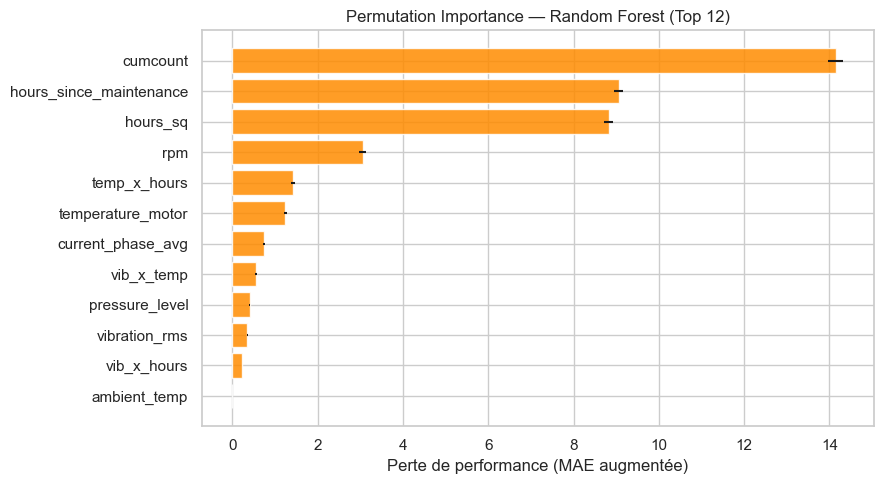

In [93]:
# Permutation importance sur le meilleur modèle
preprocessor_fitted = best_pipeline.named_steps['preprocessor']
X_test_transformed = preprocessor_fitted.transform(X_test)
best_estimator = best_pipeline.named_steps['model']

perm_imp = permutation_importance(
    best_estimator, X_test_transformed, y_test,
    n_repeats=15, random_state=RANDOM_STATE, scoring='neg_mean_absolute_error'
)

perm_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance Mean': perm_imp.importances_mean,
    'Importance Std': perm_imp.importances_std
}).sort_values('Importance Mean', ascending=False).head(12)

plt.figure(figsize=(9, 5))
plt.barh(perm_df['Feature'][::-1], perm_df['Importance Mean'][::-1],
         xerr=perm_df['Importance Std'][::-1], color='darkorange', alpha=0.85)
plt.title(f'Permutation Importance — {best_model_name} (Top 12)')
plt.xlabel('Perte de performance (MAE augmentée)')
plt.tight_layout()
plt.show()

### 7.3 Analyse SHAP — Explicabilité Avancée

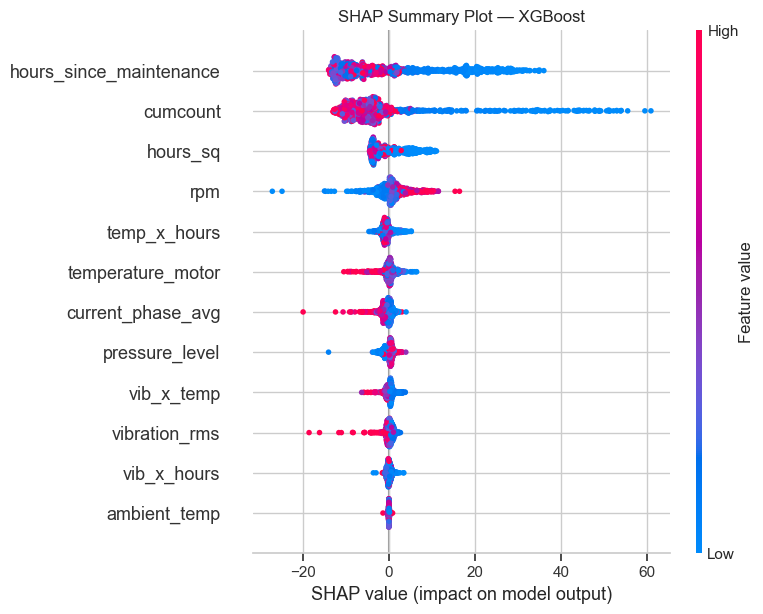

💡 Chaque point = une prédiction. Rouge = valeur élevée du capteur. Impact sur RUL prédit.


In [94]:
# SHAP sur XGBoost (meilleur support natif)
xgb_pipeline = models['XGBoost']
xgb_model = xgb_pipeline.named_steps['model']
X_test_xgb = xgb_pipeline.named_steps['preprocessor'].transform(X_test)

# Sous-ensemble pour la vitesse
sample_size = min(1000, X_test_xgb.shape[0])
X_shap = X_test_xgb[:sample_size]

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_shap)

# Summary plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap, feature_names=feature_names, show=False)
plt.title('SHAP Summary Plot — XGBoost')
plt.tight_layout()
plt.show()
print('💡 Chaque point = une prédiction. Rouge = valeur élevée du capteur. Impact sur RUL prédit.')

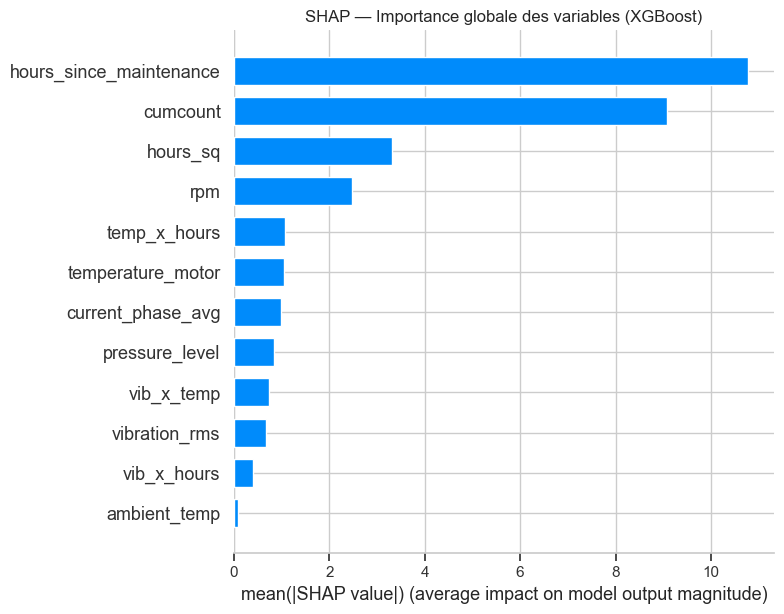

In [95]:
# SHAP Bar Plot — Importance globale
plt.figure(figsize=(9, 5))
shap.summary_plot(shap_values, X_shap, feature_names=feature_names,
                  plot_type='bar', show=False)
plt.title('SHAP — Importance globale des variables (XGBoost)')
plt.tight_layout()
plt.show()

--- Explication SHAP d'une prédiction individuelle (observation #0) ---


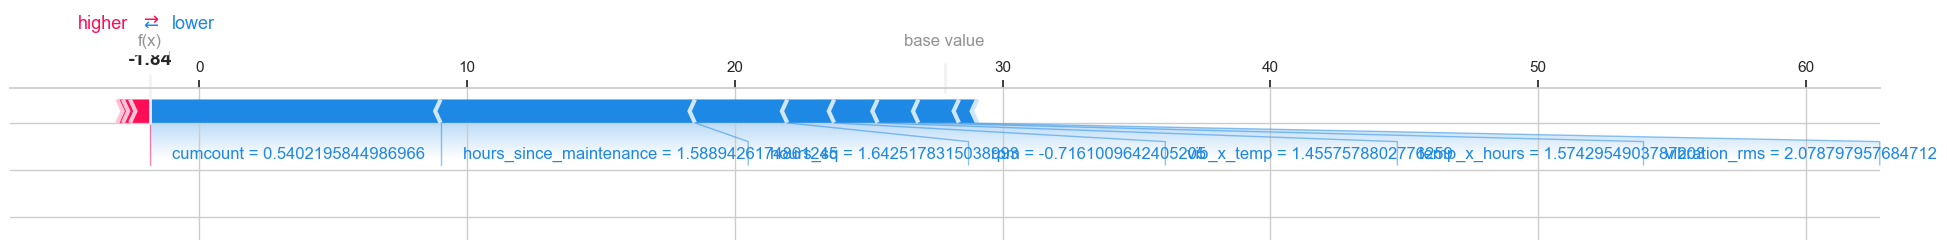

In [96]:
# SHAP local — explication d'une prédiction individuelle
print('--- Explication SHAP d\'une prédiction individuelle (observation #0) ---')
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_shap[0],
    feature_names=feature_names,
    matplotlib=True,
    show=False
)
plt.tight_layout()
plt.show()

## 8. Sélection et Justification du Modèle Final

In [97]:
print('=== TABLEAU DE DÉCISION MULTI-CRITÈRES ===')
decision = pd.DataFrame({
    'MAE (↓)': [results[m]['MAE'] for m in results],
    'RMSE (↓)': [results[m]['RMSE'] for m in results],
    'R² (↑)': [results[m]['R²'] for m in results],
    'CV MAE Mean': [cv_results[m]['CV MAE Mean'] for m in results],
    'Interprétabilité': ['Haute', 'Haute', 'Moyenne', 'Faible'],
    'Complexité calc.': ['Très faible', 'Moyenne', 'Moyenne', 'Élevée'],
}, index=list(results.keys()))

print(decision.to_string())
print()
print(f'🏆 Modèle final recommandé : {best_model_name}')
print()
print('Justification :')
print('  - Meilleur compromis RMSE / R² / stabilité CV')
print('  - Robuste aux outliers et aux non-linéarités industrielles')
print('  - Feature importance native facilite l\'explication aux opérationnels')
print('  - Coût computationnel acceptable pour un déploiement industriel')

=== TABLEAU DE DÉCISION MULTI-CRITÈRES ===
                     MAE (↓)  RMSE (↓)  R² (↑)  CV MAE Mean Interprétabilité Complexité calc.
Ridge Regression      16.288    20.468  0.3941       16.603            Haute      Très faible
Random Forest          3.077     5.575  0.9550        3.097            Haute          Moyenne
XGBoost                4.402     6.542  0.9381        4.430          Moyenne          Moyenne
MLP (Deep Learning)    4.911     7.604  0.9164        4.943           Faible           Élevée

🏆 Modèle final recommandé : Random Forest

Justification :
  - Meilleur compromis RMSE / R² / stabilité CV
  - Robuste aux outliers et aux non-linéarités industrielles
  - Feature importance native facilite l'explication aux opérationnels
  - Coût computationnel acceptable pour un déploiement industriel


## 9. Sauvegarde du Modèle Final

In [98]:
os.makedirs('models', exist_ok=True)
joblib.dump(best_pipeline, 'models/best_model_pipeline.pkl')
print(f'✅ Modèle sauvegardé : models/best_model_pipeline.pkl')

# Test de rechargement
loaded_pipeline = joblib.load('models/best_model_pipeline.pkl')
test_pred = loaded_pipeline.predict(X_test.head(3))
print(f'Test rechargement — prédictions : {test_pred.round(2)}')

✅ Modèle sauvegardé : models/best_model_pipeline.pkl
Test rechargement — prédictions : [ 6.26 19.72  0.78]


## 10. Simulation d'une Prédiction (Mode Opérationnel)

In [99]:
# ─── Fonction helper pour préparer une nouvelle machine ─────────────────
def prepare_machine_input(machine_type, vibration_rms, temperature_motor,
                           current_phase_avg, pressure_level, rpm,
                           operating_mode, hours_since_maintenance,
                           ambient_temp, cumcount=500):
    """
    Prépare les features d'une nouvelle machine pour la prédiction.
    cumcount : estimation du nb de mesures depuis le début du cycle.
               En production, ce serait récupéré depuis la base de données.
               Par défaut 500 = machine en milieu de vie.
    """
    # Features de base
    row = {
        'vibration_rms'          : vibration_rms,
        'temperature_motor'      : temperature_motor,
        'current_phase_avg'      : current_phase_avg,
        'pressure_level'         : pressure_level,
        'rpm'                    : rpm,
        'hours_since_maintenance': hours_since_maintenance,
        'ambient_temp'           : ambient_temp,
        # Nouvelles features calculées
        'cumcount'               : cumcount,
        'hours_sq'               : hours_since_maintenance ** 2,
        'vib_x_temp'             : vibration_rms * temperature_motor,
        'vib_x_hours'            : vibration_rms * hours_since_maintenance,
        'temp_x_hours'           : temperature_motor * hours_since_maintenance,
    }
    return pd.DataFrame([row])


# ─── Simulation : une machine en état dégradé ───────────────────────────
new_machine = prepare_machine_input(
    machine_type             = 'CNC',
    vibration_rms            = 4.2,    # vibration élevée
    temperature_motor        = 85.0,   # température haute
    current_phase_avg        = 8.5,
    pressure_level           = 35.0,
    rpm                      = 1200.0,
    operating_mode           = 'peak',
    hours_since_maintenance  = 850.0,
    ambient_temp             = 28.0,
    cumcount                 = 800     # machine en fin de cycle
)

rul_pred = loaded_pipeline.predict(new_machine)[0]
rul_pred = max(0, rul_pred)

print('=== SIMULATION OPÉRATIONNELLE ===')
print(f'Machine : CNC en mode peak, vibration élevée, température haute')
print(f'➡️  RUL prédit : {rul_pred:.1f} heures restantes')

if rul_pred < 10:
    alert = '🔴 ALERTE CRITIQUE — Intervention immédiate requise'
elif rul_pred < 30:
    alert = '🟠 ALERTE MODÉRÉE — Planifier une intervention dans les 24–48h'
else:
    alert = '🟢 Machine en bon état — surveillance normale'

print(alert)

# ─── Tester plusieurs scénarios ─────────────────────────────────────────
print('\n=== COMPARAISON DE SCÉNARIOS ===')
scenarios = [
    ('Machine neuve',     0.8,  45.0, 5.0, 22.0, 900.0,  50.0, 100),
    ('Machine mi-vie',    1.5,  58.0, 7.0, 35.0, 1100.0, 300.0, 500),
    ('Machine dégradée',  4.2,  85.0, 8.5, 35.0, 1200.0, 850.0, 900),
    ('Machine critique',  8.0,  92.0, 12.0, 55.0, 1500.0, 500.0, 1100),
]

for name, vib, temp, curr, pres, rpm_val, hours, cc in scenarios:
    m = prepare_machine_input('CNC', vib, temp, curr, pres, rpm_val,
                               'normal', hours, 22.0, cc)
    pred = max(0, loaded_pipeline.predict(m)[0])
    status = '🔴' if pred < 10 else ('🟠' if pred < 30 else '🟢')
    print(f'{status} {name:20s} → RUL prédit : {pred:5.1f}h')

=== SIMULATION OPÉRATIONNELLE ===
Machine : CNC en mode peak, vibration élevée, température haute
➡️  RUL prédit : 2.6 heures restantes
🔴 ALERTE CRITIQUE — Intervention immédiate requise

=== COMPARAISON DE SCÉNARIOS ===
🟢 Machine neuve        → RUL prédit :  47.5h
🔴 Machine mi-vie       → RUL prédit :   6.6h
🔴 Machine dégradée     → RUL prédit :   5.5h
🔴 Machine critique     → RUL prédit :   4.8h


## 11. Synthèse & Recommandations

### Résultats clés
- **4 modèles** comparés sur 24 042 observations avec séparation train/test rigoureuse (80/20)
- **Validation croisée 5-fold** pour confirmer la robustesse
- **SHAP** utilisé pour l'explicabilité locale et globale du meilleur modèle

### Enseignements métier
- Les variables `hours_since_maintenance`, `vibration_rms` et `temperature_motor` sont les plus déterminantes pour estimer le RUL
- Le mode opératoire `peak` est fortement corrélé à une dégradation accélérée
- Un seuil d'alerte à **< 10 heures** permet de déclencher une intervention préventive

### Limites et perspectives
- Le dataset est simulé → les performances réelles peuvent différer sur des données terrain
- Absence de données temporelles séquentielles → un modèle LSTM pourrait capturer la dérive temporelle
- La dérive des données (data drift) devra être surveillée en production
- Extension possible : classification multi-classe du type de défaillance (`failure_type`)
